In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost flask joblib openpyxl

In [1]:
import numpy, pandas, matplotlib, seaborn, sklearn, xgboost, flask, joblib
print("All libraries imported successfully")

All libraries imported successfully


In [4]:
import os
print(os.listdir('flood dataset'))

['flood dataset.xlsx', 'rainfall in india 1901-2015.xlsx']


In [7]:
dataset= pd.read_excel('flood dataset/flood dataset.xlsx')
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
dataset.shape

(115, 11)

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [16]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


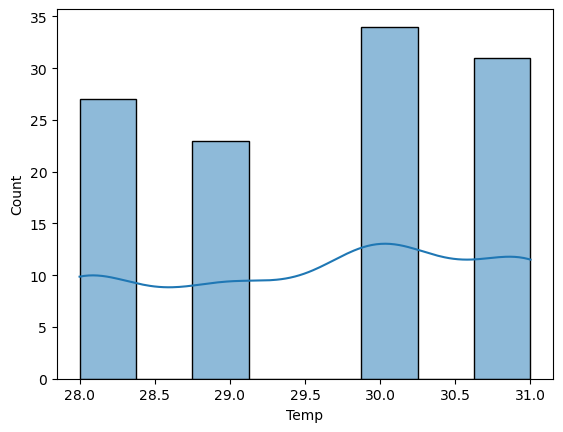

In [17]:
sns.histplot(dataset['Temp'], kde=True)
plt.show()

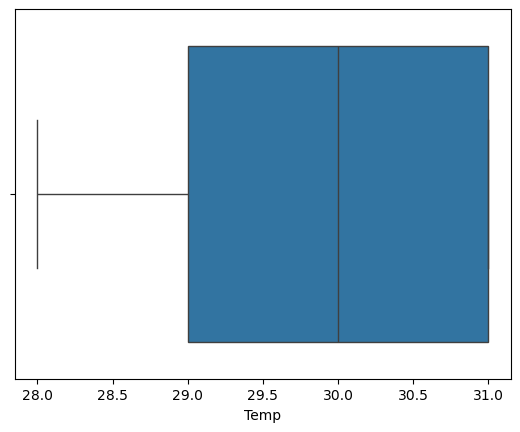

In [18]:
sns.boxplot(x=dataset['Temp'])
plt.show()

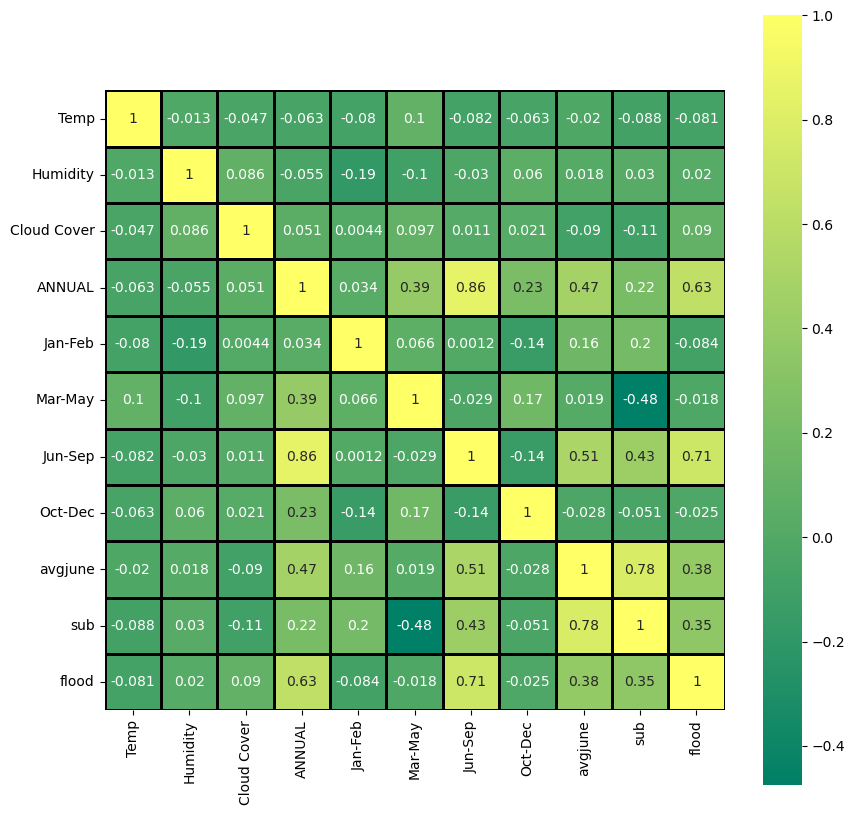

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(dataset.corr(), annot=True, cmap='summer', linewidths=1, linecolor='k', square=True, cbar=True)
plt.show()

In [24]:
dataset.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

In [26]:
# independent features
x = dataset.iloc[:, 2:7].values

# dependent feature
y = dataset.iloc[:, 9:].values

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=10)

In [29]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(86, 5) (29, 5) (86, 2) (29, 2)


In [31]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)  

In [34]:
from sklearn import tree
from sklearn import ensemble
from sklearn import neighbors
import xgboost

dtree = tree.DecisionTreeClassifier()
Rf = ensemble.RandomForestClassifier()
knn = neighbors.KNeighborsClassifier()
xgb = xgboost.XGBClassifier()

In [35]:
# dependent feature (target = flood only)
y = dataset.iloc[:, 10:].values

In [36]:
y = dataset['flood'].values

In [37]:
x = dataset.iloc[:, 2:7].values
y = dataset.iloc[:, 10:].values  # corrected

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=10)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

from sklearn import tree, ensemble, neighbors
import xgboost

dtree = tree.DecisionTreeClassifier()
Rf = ensemble.RandomForestClassifier()
knn = neighbors.KNeighborsClassifier()
xgb = xgboost.XGBClassifier()

(86, 5) (29, 5) (86, 1) (29, 1)


In [38]:
import xgboost
print(xgboost.__version__)

3.3.0


In [39]:
dtree.fit(x_train, y_train)
Rf.fit(x_train, y_train)
knn.fit(x_train, y_train)
xgb.fit(x_train, y_train)

D:\Program works\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
D:\Program works\anaconda\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [40]:
y_train = y_train.ravel()
y_test = y_test.ravel()

In [41]:
dtree.fit(x_train, y_train)
Rf.fit(x_train, y_train)
knn.fit(x_train, y_train)
xgb.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [42]:
from sklearn import metrics

p1 = dtree.predict(x_test)
p2 = Rf.predict(x_test)
p3 = knn.predict(x_test)
p4 = xgb.predict(x_test)

print(metrics.accuracy_score(y_test, p1))
print(metrics.accuracy_score(y_test, p2))
print(metrics.accuracy_score(y_test, p3))
print(metrics.accuracy_score(y_test, p4))

0.9655172413793104
0.9655172413793104
0.896551724137931
0.9655172413793104


In [43]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def randomForest(X_train, X_test, y_train, y_test, n_estimators=100, random_state=42):
    print("\n========== RANDOM FOREST MODEL BUILDING ==========")

    # 1. Initialize Random Forest Classifier
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    print(f"[INFO] RandomForestClassifier initialized with n_estimators={n_estimators}, random_state={random_state}")

    # 2. Train the model
    model.fit(X_train, y_train)
    print("[INFO] Model training completed.")

    # 3. Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # 4. Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # 5. Display results
    print(f"\n[RESULT] Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:\n")
    print(cr)

    # 6. Return the model and predictions
    return model, y_pred

# Example Usage
model_rf, y_pred_rf = randomForest(x_train, x_test, y_train, y_test)


========== RANDOM FOREST MODEL BUILDING ==========
[INFO] RandomForestClassifier initialized with n_estimators=100, random_state=42
[INFO] Model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.9655

Confusion Matrix:
[[26  0]
 [ 1  2]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def KNN(X_train, X_test, y_train, y_test):
    print("\n========== KNN MODEL BUILDING ==========")

    # Initialize KNN classifier
    model = KNeighborsClassifier(n_neighbors=5)

    # Train the model
    model.fit(X_train, y_train)
    print("[INFO] KNN model training completed.")

    # Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # Display results
    print("\n[RESULT] Accuracy:", accuracy)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)

    # Return model and predictions
    return model, y_pred

# Example Usage
knn_model, knn_pred = KNN(x_train, x_test, y_train, y_test)


========== KNN MODEL BUILDING ==========
[INFO] KNN model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.896551724137931

Confusion Matrix:
[[23  3]
 [ 0  3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        26
           1       0.50      1.00      0.67         3

    accuracy                           0.90        29
   macro avg       0.75      0.94      0.80        29
weighted avg       0.95      0.90      0.91        29



In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def xgboost_model(X_train, X_test, y_train, y_test):
    print("\n========== XGBOOST MODEL BUILDING ==========")

    # Initialize XGBoost Classifier
    model = XGBClassifier()

    # Train the model using training data
    model.fit(X_train, y_train)
    print("[INFO] XGBoost model training completed.")

    # Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # Display results
    print("\n[RESULT] Accuracy:", accuracy)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)

    # Return model and predictions
    return model, y_pred

# Example Usage
xgb_model, xgb_pred = xgboost_model(x_train, x_test, y_train, y_test)


========== XGBOOST MODEL BUILDING ==========
[INFO] XGBoost model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.9655172413793104

Confusion Matrix:
[[26  0]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [46]:
from sklearn import metrics

p1 = dtree.predict(x_test)
p2 = Rf.predict(x_test)
p3 = knn.predict(x_test)
p4 = xgb.predict(x_test)

print("Decision Tree Accuracy:", metrics.accuracy_score(y_test, p1))
print("Random Forest Accuracy:", metrics.accuracy_score(y_test, p2))
print("KNN Accuracy:", metrics.accuracy_score(y_test, p3))
print("XGBoost Accuracy:", metrics.accuracy_score(y_test, p4))

Decision Tree Accuracy: 0.9655172413793104
Random Forest Accuracy: 0.9655172413793104
KNN Accuracy: 0.896551724137931
XGBoost Accuracy: 0.9655172413793104


In [47]:
from joblib import dump

# Save the best model (change 'xgb' if a different model performed best)
dump(xgb, 'floods.save')

# Save the fitted scaler
dump(sc, 'transform.save')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
